In [55]:
import json
import anndata as ad
import pandas as pd
import os
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# EXC example

## 1. UMAP + KNN results in h5ad

In [45]:
adata = ad.read_h5ad('/scratch/h5ad_outputs/exc_minnie_met_umapknn.h5ad')

In [46]:
umapknndf = adata.obs
umapknndf

,id,predicted_label
0,23141,L6b
1,23332,L6 IT-1
2,23373,L5 IT-2
3,23382,L6 IT-1
4,23385,L5 IT-2
...,...,...
49709,764787,L5/L6 IT Car3
49710,766128,L5/L6 IT Car3
49711,766409,L5/L6 IT Car3
49712,766554,L5/L6 IT Car3


## 2. MMC results in dict

In [31]:
## MMC results
with open('/data/MMC-minnie-from-patchseq-v2/exc_mapping.json', 'rb') as src:
    mapping = json.load(src)

In [32]:
mapping.keys()

dict_keys(['marker_genes', 'taxonomy_tree', 'n_unmapped_genes', 'gene_identifier_mapping', 'config', 'log', 'metadata', 'results'])

In [33]:
mapping['results'][0]

{'cluster': {'assignment': 'L6 IT-3',
  'bootstrapping_probability': 0.5,
  'aggregate_probability': 0.5,
  'avg_correlation': 0.8007693105307575,
  'runner_up_assignment': ['L6b', 'L5/L6 IT Car3'],
  'runner_up_correlation': [0.7117746375196076, 0.909296897228225],
  'runner_up_probability': [0.25, 0.25],
  'directly_assigned': True},
 'cell_id': '23141'}

### put mmc mapping results into id label table like the umap+knn results

In [34]:
mmc_df = pd.DataFrame([
    {"id": int(r["cell_id"]), "predicted_label": r["cluster"]["assignment"]}
    for r in mapping["results"]
])
mmc_df

,id,predicted_label
0,23141,L6 IT-3
1,23332,L6 IT-3
2,23373,L6 IT-3
3,23382,L6 IT-3
4,23385,L6 IT-3
...,...,...
49709,764787,L6 IT-3
49710,766128,L6 IT-3
49711,766409,L6 IT-3
49712,766554,L6 IT-3


## 3. OG Minnie Types

## Visualise

/tmp/ipykernel_184/2834813401.py:3: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  sortedlist = sorted(umapknndf.predicted_label.unique().to_list())
/tmp/ipykernel_184/2834813401.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha='right')
/tmp/ipykernel_184/2834813401.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha='right')
/tmp/ipykernel_184/2834813401.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha='right')
/tmp/ipykernel_184/2834813401.py:10: UserWarning: set_ticklabels() should only be 

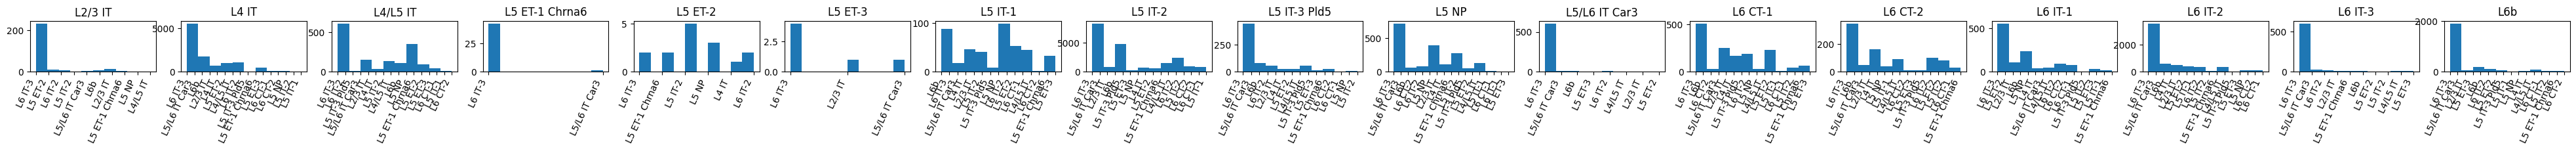

In [60]:
# distribution of mmc labels for each predicted label of umapknn

sortedlist = sorted(umapknndf.predicted_label.unique().to_list())
fig, axes = plt.subplots(nrows=1, ncols=len(sortedlist), figsize=[50,1])

for l, ll in enumerate(sortedlist):
    ax = axes[l]
    curind = umapknndf['predicted_label']==ll
    ax.hist(mmc_df['predicted_label'][curind.values])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha='right')
    ax.set_title(ll)
plt.show()